In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.integrate import solve_ivp

import tinyDA as tda

# forward model evaluations

import pyvista as pv
import ufl
from dolfinx import fem, mesh, plot, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI


from ufl import dx, grad, inner

from helpers import interpolate_nonmatching, plot_function_3d
import pyvista

## Forward Model Setup

In [3]:
class LinearElasticity:
    def __init__(self, solve_mesh: mesh, observation_mesh: mesh) -> None:
        self._observation_mesh = observation_mesh
        self._mesh = solve_mesh
        self._V = fem.functionspace(self._mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        self._V_observation = fem.functionspace(self._observation_mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        # boundary conditions
        facets_left = mesh.locate_entities_boundary(
            self._mesh,
            dim=(self._mesh.topology.dim - 1),
            marker=lambda x: np.isclose(x[0], 0.0),
        )
        dofs_left = fem.locate_dofs_topological(
            V=self._V, entity_dim=self._mesh.topology.dim - 1, entities=facets_left
        )
        bc_left = fem.dirichletbc(
            value=default_scalar_type((0,0,0)), dofs=dofs_left, V=self._V
        )


        # coefficient setup
        u = ufl.TrialFunction(self._V)
        v = ufl.TestFunction(self._V)
        f = fem.Constant(self._mesh, default_scalar_type((0,0,-0.1)))
        x = ufl.SpatialCoordinate(self._mesh)
        lam = 1
        self._mu1 = fem.Constant(self._mesh, default_scalar_type(1))
        self._mu2 = fem.Constant(self._mesh, default_scalar_type(5))
        self._mu3 = fem.Constant(self._mesh, default_scalar_type(10))

        def mu(x):
            left = np.min(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            right = np.max(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            width = right-left
            return ufl.conditional(x[0]<=left+width/3, self._mu1, ufl.conditional(x[0]<=left + 2 * width/3, self._mu2, self._mu3) )

        def epsilon(u):
            return 1/2 * (ufl.grad(u) + ufl.grad(u).T)
        def sigma(u):
            return lam * ufl.nabla_div(u) * ufl.Identity(len(u)) + mu(x) * epsilon(u)

        

        # weak formulation
        a = inner(sigma(u), epsilon(v)) * dx
        L = inner(f, v) * dx  # + inner(g, v) * ds # only dirichlet

        self._problem = LinearProblem(
            a,
            L,
            bcs=[bc_left],
            petsc_options={"ksp_type": "cg", "pc_type": "gamg"},
            petsc_options_prefix="lp",
        )

        # performance optimization
        self._cells_V_to = np.arange(
            self._V_observation.mesh.topology.index_map(
                self._V_observation.mesh.topology.dim
            ).size_local,
            dtype=np.int32,
        )
        self._interpolation_data = fem.create_interpolation_data(
            self._V_observation, self._V, self._cells_V_to
        )
        
    def _evaluate(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the PDE solution operator S."""
        self._mu1.value = np.exp(state[0])
        self._mu2.value = np.exp(state[1])
        self._mu3.value = np.exp(state[2])
        sol = self._problem.solve()
        return sol

    def __call__(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the observation operator"""
        pde_sol = self._evaluate(state)
        observed = interpolate_nonmatching(
            self._V_observation,
            self._V,
            pde_sol,
            self._interpolation_data,
            self._cells_V_to,
        )
        return observed.x.array, 0 # placeholder for qoi

    @property
    def gdim(self):
        return self._mesh.geometry.dim

    @property
    def ndofs(self):
        return self._V.dofmap.index_map.size_global

    def plot(self, solution):
        """Plot forward model output, indicate regions of different mu."""


        def mu(x):
            left = np.min(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            right = np.max(self._mesh.geometry.x[:,0]) # vertical layers, for horizontal layers set 1st component
            width = right-left
            return np.where(x[:,0]<=left+width/3, self._mu1.value, np.where(x[:,0]<=left + 2 * width/3, self._mu2.value, self._mu3.value) )

        p = pyvista.Plotter()
        topology, cell_types, geometry = plot.vtk_mesh(self._V_observation)
        grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

        # Attach vector values to grid and warp grid by vector
        u_3d = solution.reshape((geometry.shape[0], 3))

        # Plot material coefficient mu(x) (here: mu(theta(x)/eps) with theta(x)=[x1,x0] => depends on x1/eps)
        mu_vals = mu(geometry)

        grid["u"] = u_3d
        grid["mu"] = mu_vals
        warped = grid.warp_by_vector("u", factor=1.5)

        # Show only the outer boundary (no element edges)
        #boundary = grid.extract_feature_edges(
        #    boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False)
        #actor_0 = p.add_mesh(boundary, color="k", line_width=2)

        actor_0 = p.add_mesh(grid, style="wireframe", color="k")
        # Show the full deformed beam (no element edges)
        actor_1 = p.add_mesh(warped, scalars="mu", cmap="plasma", show_edges=True)
        p.add_scalar_bar(title="mu")
        p.show_axes()
        if not pyvista.OFF_SCREEN:
            p.show()
        else:
            figure_as_array = p.screenshot("deflection.png")

In [ ]:
# UNIFORM REFINEMENT (takes 1.5 minutes)

_msh = mesh.create_box(MPI.COMM_WORLD, np.array([[0,0,0],[1,0.4,0.4]]), [20,6,6]) # last array discretization
_msh.topology.create_entities(1)

_msh2 = mesh.refine(_msh)[0]
_msh2.topology.create_entities(1)

_msh3 = mesh.refine(_msh2)[0]
_msh3.topology.create_entities(1)
_msh4 = mesh.refine(_msh3)[0]
_msh4.topology.create_entities(1)
_msh_data = mesh.refine(_msh4)[0]

_obs_msh = mesh.create_rectangle(MPI.COMM_WORLD, [[0.1, 0.1], [0.9, 0.9]], [10,10]) # create_box in 3d

_obs_msh = mesh.create_box(MPI.COMM_WORLD, np.array([[0.1,0.1,0.1],[1,0.4,0.4]]), [10,3,3])

In [ ]:
# MODEL HIERARCHY (takes 1.5 minutes)

model1 = LinearElasticity(_msh, _obs_msh)
model2 = LinearElasticity(_msh2, _obs_msh)

model_data = LinearElasticity(_msh_data, _obs_msh)

## Inverse Problem Setup

In [8]:
# set true parameter(s)

mu1 = np.log(10)
mu2 = np.log(5)
mu3 = np.log(1)

true_parameters = np.array([mu1, mu2, mu3]) # no log

x_true = model2(true_parameters)[0] # true displacement
x_true.shape

# generate data

sigma = 0.003

noise = np.random.normal(scale=sigma, size=(x_true.shape[0]))
data = x_true+noise

In [9]:
plot_function_3d(model2._V_observation, data)

Widget(value='<iframe src="http://localhost:63474/index.html?ui=P_0x16dfe77d0_0&reconnect=auto" class="pyvista…

In [10]:
model2.plot(data)

Widget(value='<iframe src="http://localhost:63474/index.html?ui=P_0x3361b5c10_1&reconnect=auto" class="pyvista…

In [11]:
#uniform_prior = stats.uniform(loc=np.log(0.5), scale=bnp.log(1.5)-np.log(0.5))
#uniform_prior = stats.uniform(loc=0, scale=2)

prior_mu1 = stats.uniform(loc=np.log(0.001), scale=np.log(100)-np.log(0.001))
prior_mu2 = stats.uniform(loc=np.log(0.001), scale=np.log(100)-np.log(0.001))
prior_mu3 = stats.uniform(loc=np.log(0.001), scale=np.log(100)-np.log(0.001))

my_prior = tda.CompositePrior([prior_mu1, prior_mu2, prior_mu3])

/Users/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/tinyDA/distributions.py:105: UserWarning:  CompositePrior has been deprecated. Please use JointPrior.
  warnings.warn(" CompositePrior has been deprecated. Please use JointPrior.")


In [12]:
cov_likelihood = sigma**2*np.eye(data.size)

loglike = tda.GaussianLogLike(data, cov_likelihood)

my_posterior_l2 = tda.Posterior(my_prior, loglike, model2)
my_posterior_l1 = tda.Posterior(my_prior, loglike, model1)
#my_posterior_l0 = tda.Posterior(my_prior, loglike, gaussian)

my_posteriors = [my_posterior_l1, my_posterior_l2]

In [13]:
my_posterior = tda.Posterior(my_prior, loglike, model1)

In [11]:
#MAP = tda.get_MAP(my_posterior)
#print(MAP)


In [14]:
# random walk Metropolis
#rwmh_cov = np.eye(1)
#rmwh_scaling = 0.1
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# Adaptive Metropolis
#am_cov = np.eye(true_parameters.size)
#am_t0 = 100
#am_sd = None
#am_epsilon = 1e-6
#am_adaptive = True
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

dream_m0 = 1000
dream_delta = 1
dream_Z_method = 'lhs'
dream_adaptive = True
my_proposal = tda.DREAMZ(M0=dream_m0, delta=dream_delta, Z_method=dream_Z_method, adaptive=dream_adaptive)

In [ ]:
my_chain = tda.sample(my_posteriors, my_proposal, iterations=1000, n_chains=1, subchain_length=10, initial_parameters=MAP)

Sampling chain 1/1


Running chain, α_c = 0.217, α_f = 0.03: 100%|██████████| 1000/1000 [26:48<00:00,  1.61s/it] 


In [16]:
import arviz as az
#samples = tda.to_inference_data(my_chain, burnin=2000)

idata = tda.to_inference_data(my_chain, burnin=300, parameter_names = ['log(mu1)', 'log(mu2)', 'log(mu3)'])

/Users/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [17]:
az.summary(idata)

arviz - WARNING - Shape validation failed: input_shape: (1, 701), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log(mu1),2.302,0.000,2.301,2.302,0.000,0.000,2.0,21.0,NaN
log(mu2),1.610,0.002,1.607,1.612,0.002,0.002,1.0,7.0,NaN
log(mu3),-0.000,0.004,-0.003,0.009,0.003,0.002,1.0,7.0,NaN


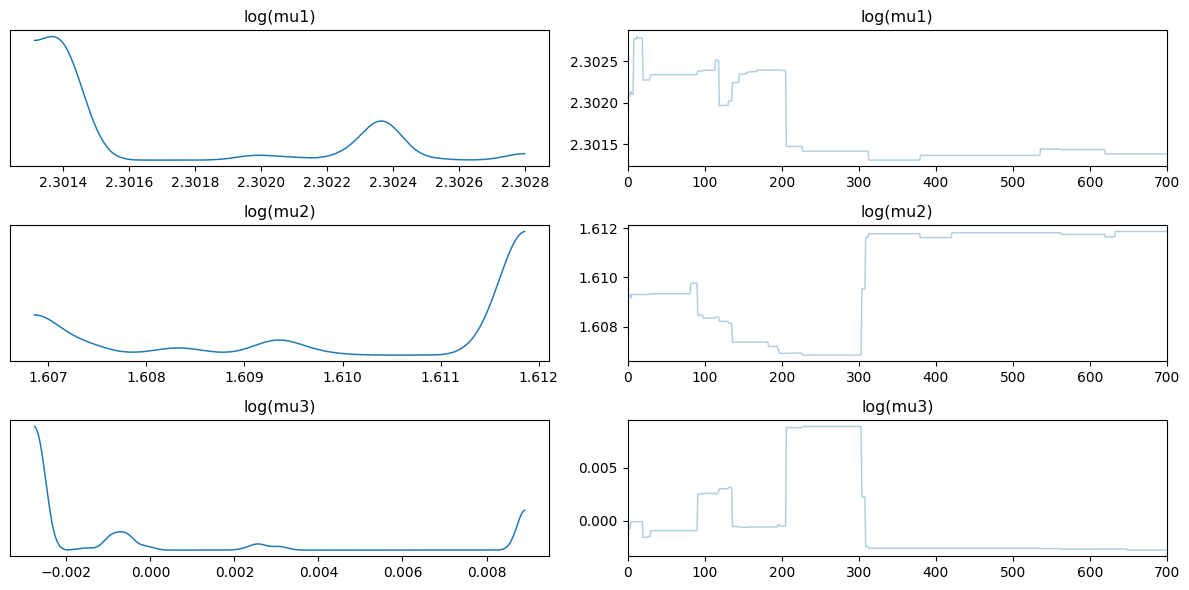

: 

In [ ]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()

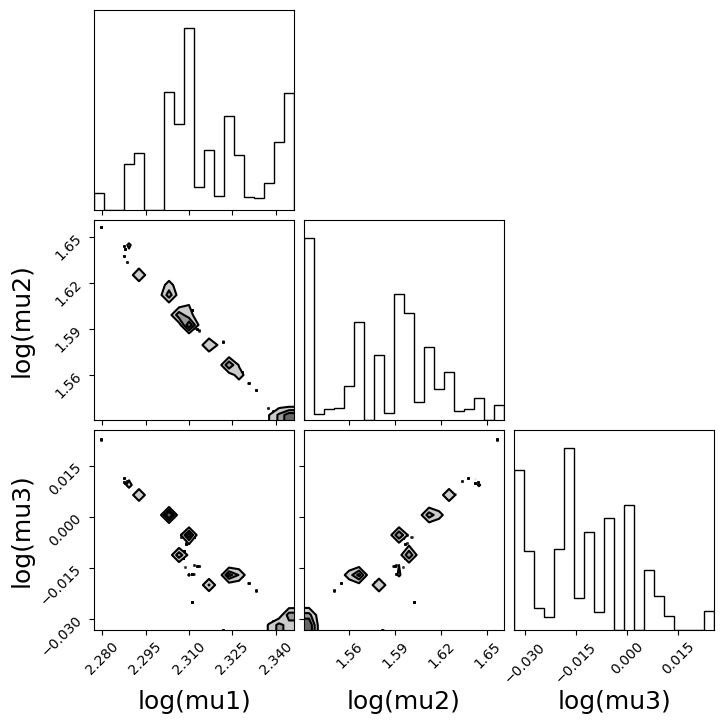

In [45]:
import corner

figure = corner.corner(idata, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)
